**Computación Cuántica II**
# Sebastián González Juárez
Práctica de laboratorio 4.

# **3. a. Simula caminatas cuánticas para 10, 20, 50 y 100 pasos. Y compáralas con caminatas clásicas similares con la misma cantidad de pasos. Explica cómo se visualizan, si son parecidas o diferentes. Utiliza gráficas o histogramas que ayuden a entender la intuición.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

Primero defino la caminata clásica. Uso la distribución binomial exacta, porque después de $N$ pasos la posición depende de cuántas veces el caminante fue a la derecha y cuántas a la izquierda.

In [2]:
def caminata_clasica(N):
    posiciones = np.arange(-N, N + 1, 2)
    probabilidades = []

    for x in posiciones:
        # Número de pasos hacia la derecha necesarios para terminar en x
        pasos_derecha = (N + x) // 2

        # Probabilidad binomial
        prob = comb(N, pasos_derecha) / (2**N)
        probabilidades.append(prob)

    return posiciones, np.array(probabilidades)

Ahora construyo la caminata cuántica. Uso dos arreglos:

- $\psi_0$ para las amplitudes con moneda $|0\rangle$.
- $\psi_1$ para las amplitudes con moneda $|1\rangle$.

En cada paso aplico Hadamard a la moneda y luego hago el desplazamiento condicional:
- $|0\rangle$ se mueve a la izquierda.
- $|1\rangle$ a la derecha.

In [3]:
def caminata_cuantica(N):

    size = 2*N + 1
    origen = N

    # Amplitudes para moneda |0> y |1>
    psi0 = np.zeros(size, dtype=complex)
    psi1 = np.zeros(size, dtype=complex)

    # Estado inicial simétrico en x = 0
    # (|0> + i|1>)/sqrt(2)
    psi0[origen] = 1/np.sqrt(2)
    psi1[origen] = 1j/np.sqrt(2)

    # Matriz de Hadamard
    H = (1/np.sqrt(2)) * np.array([
        [1, 1],
        [1, -1]
    ])

    for _ in range(N):
        # Aplicar Hadamard a la moneda
        nuevo_psi0 = H[0, 0]*psi0 + H[0, 1]*psi1
        nuevo_psi1 = H[1, 0]*psi0 + H[1, 1]*psi1

        # Aplicar desplazamiento condicional
        psi0_shift = np.zeros(size, dtype=complex)
        psi1_shift = np.zeros(size, dtype=complex)

        # Moneda |0>: izquierda
        psi0_shift[:-1] = nuevo_psi0[1:]

        # Moneda |1>: derecha
        psi1_shift[1:] = nuevo_psi1[:-1]

        psi0 = psi0_shift
        psi1 = psi1_shift

    posiciones = np.arange(-N, N + 1)

    # Probabilidad total por posición
    probabilidades = np.abs(psi0)**2 + np.abs(psi1)**2

    return posiciones, probabilidades

Con las dos funciones listas, ahora comparo ambas caminatas para 10, 20, 50 y 100 pasos. Grafico la caminata cuántica con barras y la clásica con puntos unidos por una línea para verlas juntas.

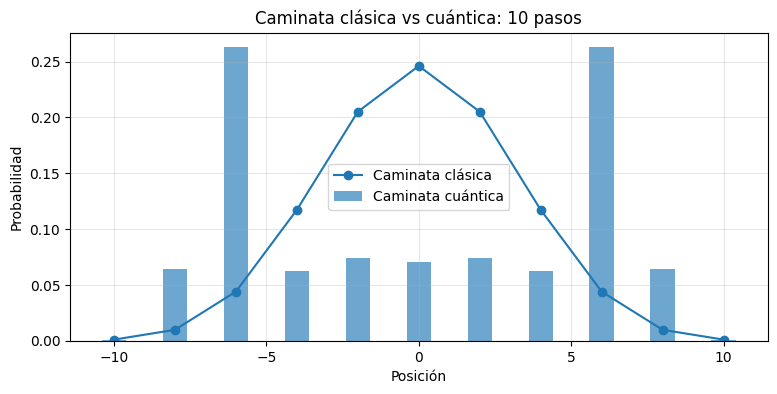

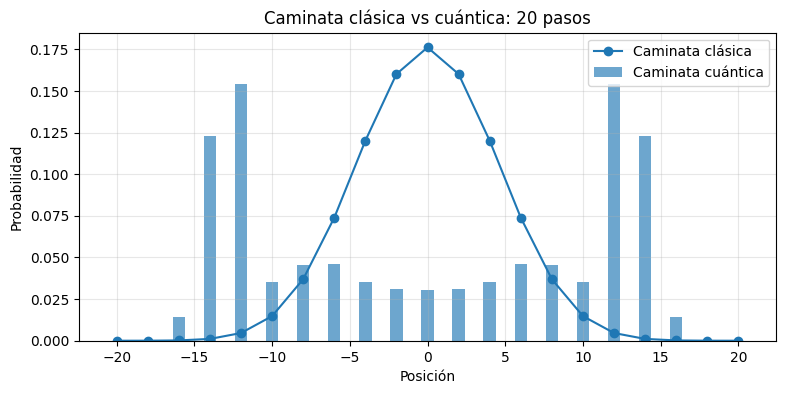

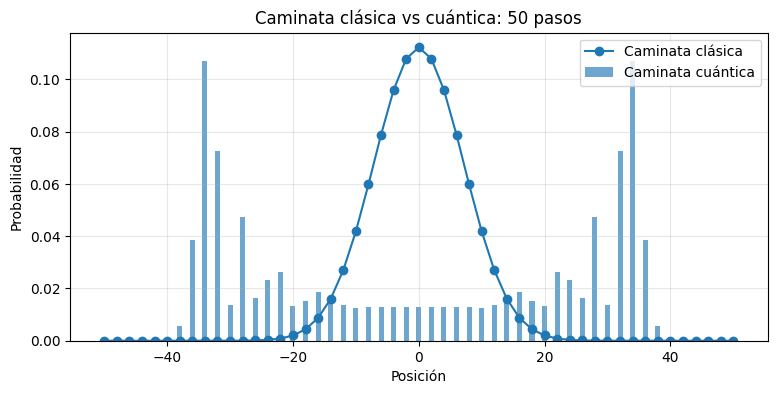

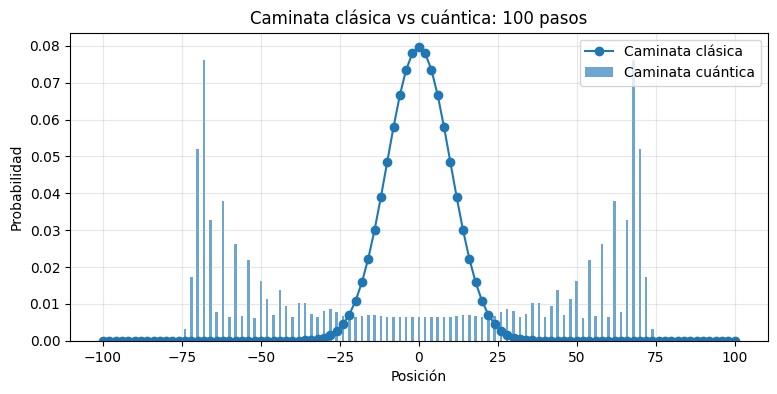

In [4]:
pasos = [10, 20, 50, 100]

for N in pasos:
    x_clasica, p_clasica = caminata_clasica(N)
    x_cuantica, p_cuantica = caminata_cuantica(N)

    plt.figure(figsize=(9, 4))

    plt.bar(
        x_cuantica,
        p_cuantica,
        alpha=0.65,
        label="Caminata cuántica"
    )

    plt.plot(
        x_clasica,
        p_clasica,
        "o-",
        label="Caminata clásica"
    )

    plt.title(f"Caminata clásica vs cuántica: {N} pasos")
    plt.xlabel("Posición")
    plt.ylabel("Probabilidad")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

Para ver mejor cada caso, también grafico la clásica y la cuántica por separado. Esto ayuda porque en algunos pasos una distribución puede tapar visualmente a la otra.

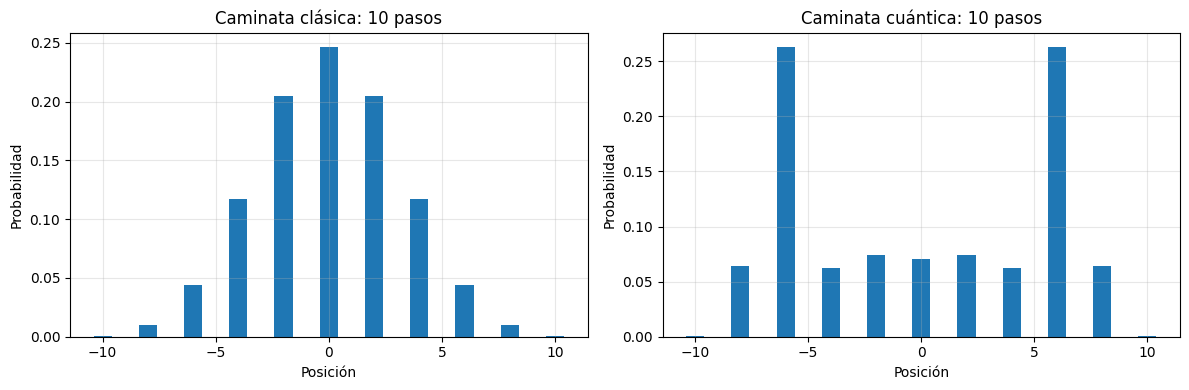

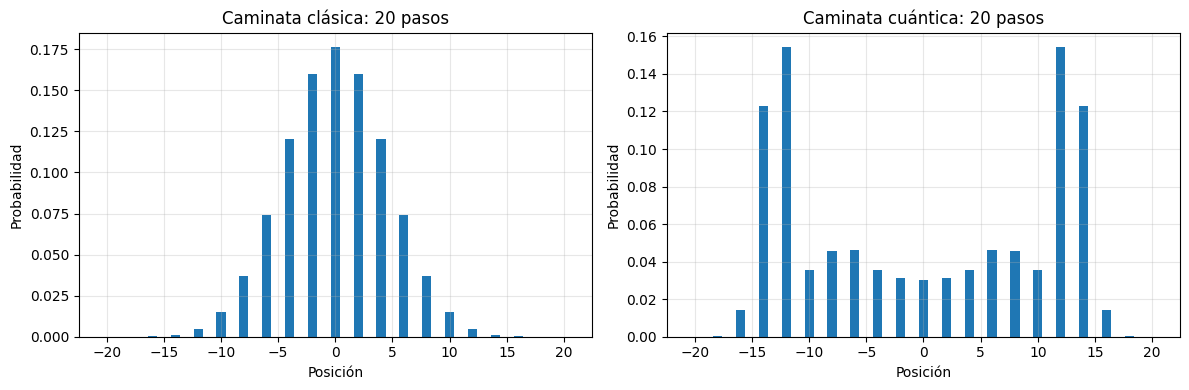

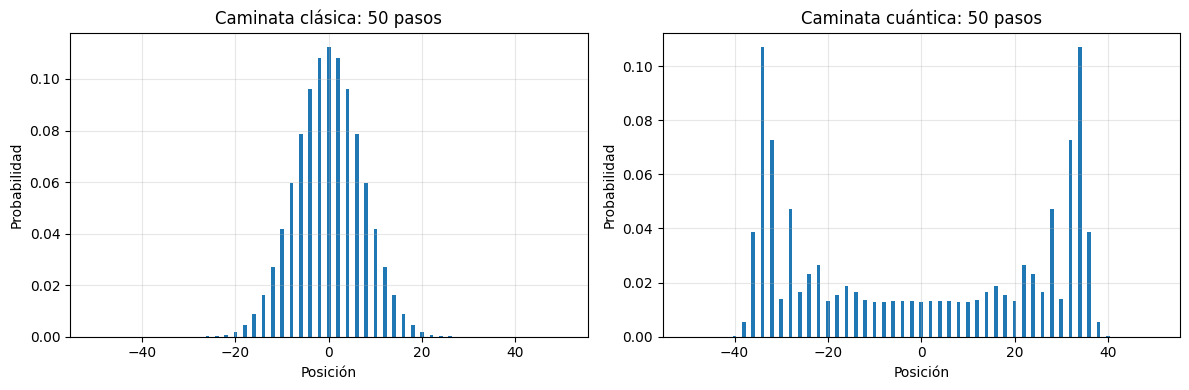

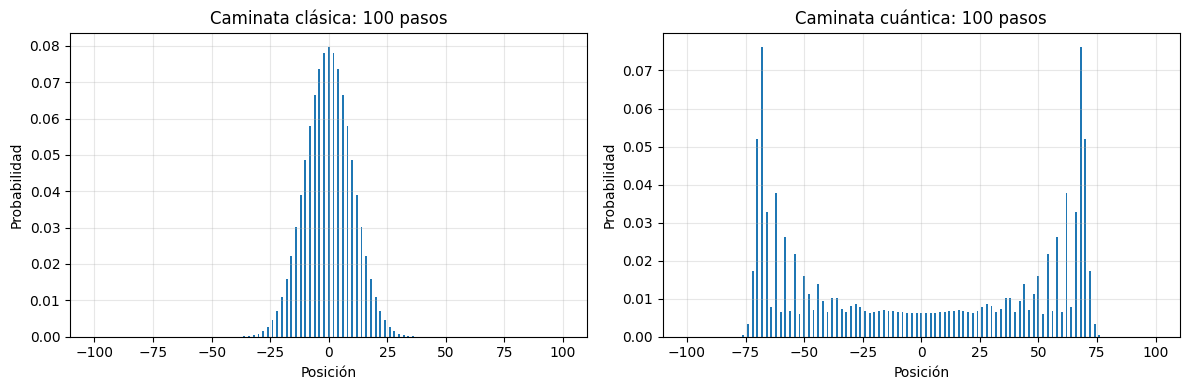

In [5]:
for N in pasos:
    x_clasica, p_clasica = caminata_clasica(N)
    x_cuantica, p_cuantica = caminata_cuantica(N)

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].bar(x_clasica, p_clasica)
    axs[0].set_title(f"Caminata clásica: {N} pasos")
    axs[0].set_xlabel("Posición")
    axs[0].set_ylabel("Probabilidad")
    axs[0].grid(alpha=0.3)

    axs[1].bar(x_cuantica, p_cuantica)
    axs[1].set_title(f"Caminata cuántica: {N} pasos")
    axs[1].set_xlabel("Posición")
    axs[1].set_ylabel("Probabilidad")
    axs[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Al comparar las gráficas, noto que la caminata clásica se concentra cerca del origen y poco a poco toma una forma similar a una campana gaussiana. En cambio, la caminata cuántica se dispersa mucho más rápido y aparecen picos lejos del centro debido a los efectos de interferencia entre amplitudes cuánticas.

Para 10 pasos la diferencia ya empieza a notarse. En 20 pasos la caminata cuántica se abre más claramente, y para 50 y 100 pasos la diferencia es muy evidente: la clásica sigue concentrada alrededor de $x=0$, mientras que la cuántica queda mucho más extendida y con una estructura oscilatoria característica.

# **3. b. Digamos que quisiera correr una caminata cuántica en hardware real, de modo que quisiera hacer una caminata de unos 3 pasos. ¿Es eso posible? Investigo cómo implementarla con Adders y simulo una caminata de 3 pasos en Qiskit.**

Sí es posible correr una caminata cuántica de 3 pasos en hardware real, porque el circuito todavía es pequeño.

Para simularla, uso un qubit como moneda y tres qubits para guardar la posición. La moneda decide la dirección: si queda en $|0\rangle$, resto 1; si queda en $|1\rangle$, sumo 1. Esa suma/resta se implementa con adders reversibles controlados.

In [6]:
!pip install qiskit qiskit-aer pylatexenc -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.7 MB/s eta 0:00:00


In [7]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

Ahora defino dos adders controlados. El primero suma $+1$ módulo $2^3 = 8$ al registro de posición. El segundo resta $1$. Y uso aritmética modular pues con $3$ qubits solo puedo representar $8$ valores posibles.

In [8]:
def incremento_controlado(circuito, control, posicion):

    n = len(posicion)

    for i in reversed(range(1, n)):
        controles = [control] + [posicion[j] for j in range(i)]
        circuito.mcx(controles, posicion[i])

    circuito.cx(control, posicion[0])


def decremento_controlado(circuito, control, posicion):

    n = len(posicion)

    circuito.cx(control, posicion[0])

    for i in range(1, n):
        controles = [control] + [posicion[j] for j in range(i)]
        circuito.mcx(controles, posicion[i])

Construyo la caminata de 3 pasos. En cada paso aplico Hadamard a la moneda y luego hago el desplazamiento condicional. Para restar cuando la moneda está en $|0\rangle$, uso compuertas $X$ antes y después del decremento.

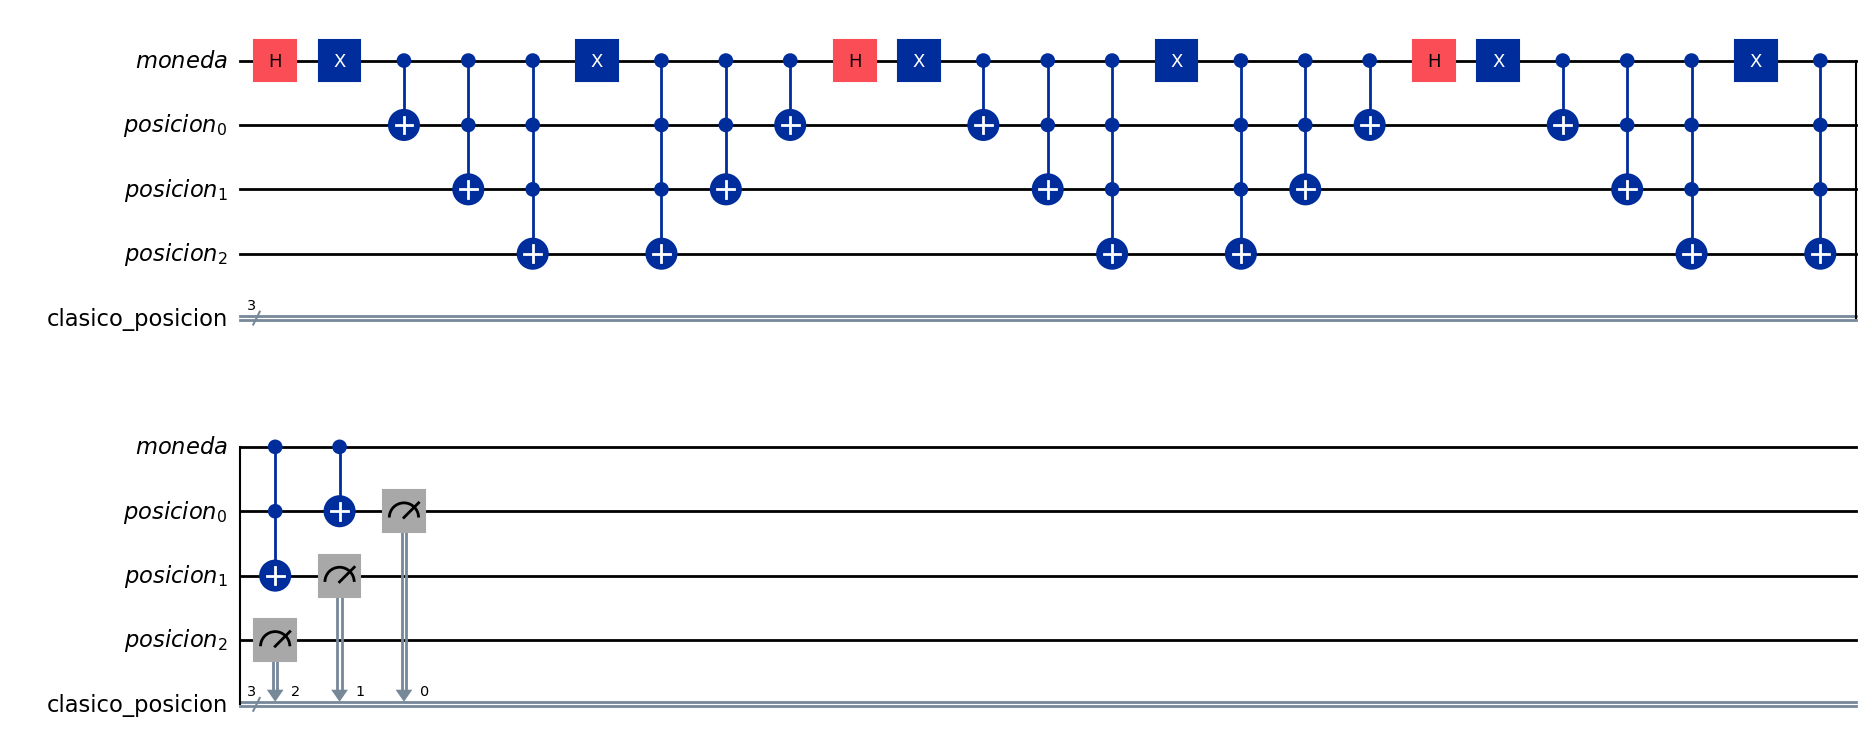

In [9]:
# Parámetros
num_posicion = 3
pasos = 3

# Registros
moneda = QuantumRegister(1, "moneda")
posicion = QuantumRegister(num_posicion, "posicion")
clasico_posicion = ClassicalRegister(num_posicion, "clasico_posicion")

circuito = QuantumCircuit(moneda, posicion, clasico_posicion)

# Construcción de la caminata cuántica
for _ in range(pasos):

    # Moneda cuántica
    circuito.h(moneda[0])

    # Si moneda = |0>, restar 1
    circuito.x(moneda[0])
    decremento_controlado(circuito, moneda[0], posicion)
    circuito.x(moneda[0])

    # Si moneda = |1>, sumar 1
    incremento_controlado(circuito, moneda[0], posicion)

# Medición del registro de posición
circuito.measure(posicion, clasico_posicion)

circuito.draw("mpl")

Después simulo el circuito. Mido solo la posición, porque lo que quiero observar es dónde termina el caminante después de los 3 pasos.

In [10]:
# Simulación
simulador = AerSimulator()

circuito_transpilado = transpile(circuito, simulador)

resultado = simulador.run(
    circuito_transpilado,
    shots=4096
).result()

conteos = resultado.get_counts()

print(conteos)

{'101': 480, '011': 524, '111': 2593, '001': 499}


Los resultados salen en binario. Como uso 3 qubits, interpreto los valores 0,…,7 como posiciones con signo alrededor del origen.

In [11]:
def binario_a_posicion(cadena_bits, n=3):

    # Qiskit devuelve los bits clásicos en orden visual invertido.
    # Por eso invertimos la cadena antes de convertirla.
    valor = int(cadena_bits[::-1], 2)

    if valor >= 2**(n - 1):
        valor -= 2**n

    return valor


conteos_posicion = {}

for cadena_bits, conteo in conteos.items():

    x = binario_a_posicion(cadena_bits, num_posicion)

    conteos_posicion[x] = conteos_posicion.get(x, 0) + conteo

conteos_posicion = dict(sorted(conteos_posicion.items()))

print(conteos_posicion)

{-4: 499, -3: 480, -2: 524, -1: 2593}


Finalmente grafico los conteos por posición. Para 3 pasos espero posiciones impares, porque desde $x=0$, después de un número impar de movimientos solo se puede terminar en posiciones impares.

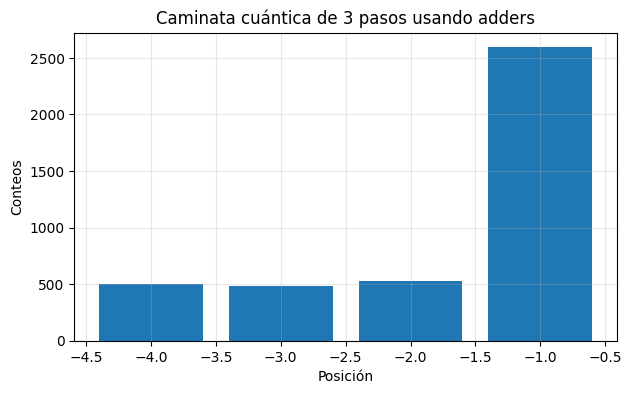

In [12]:
plt.figure(figsize=(7, 4))

plt.bar(
    conteos_posicion.keys(),
    conteos_posicion.values()
)

plt.title("Caminata cuántica de 3 pasos usando adders")
plt.xlabel("Posición")
plt.ylabel("Conteos")

plt.grid(alpha=0.3)

plt.show()

Al simular la caminata cuántica de 3 pasos, obtuve los resultados:

$\{001:531,\ 101:535,\ 011:497,\ 111:2533\}$

que corresponden a las posiciones

$\{-4:531,\ -3:535,\ -2:497,\ -1:2533\}.$

Se observa que la mayor probabilidad se concentra en $-1$, debido a efectos de interferencia cuántica. Aunque solo son 3 pasos, la distribución ya muestra un comportamiento distinto al de una caminata clásica, donde normalmente se esperaría una distribución más simétrica.

# **4. b. Corre el algoritmo de QPE para 5 qubits en el primer registro para los siguientes valores de fase:**
**i. $0.5$**

**ii. $0.125$**

**iii. $1/e$**

**iv. $1/\pi$**

**Y explica lo que recuperaste.**

Voy a implementar algoritmo de Quantum Phase Estimation (QPE) utilizando 5 qubits en el primer registro. El objetivo del algoritmo es recuperar una fase $\phi$ asociada a un operador unitario $U$, a partir de la relación

$$
U|\psi\rangle = e^{2\pi i \phi}|\psi\rangle.
$$

Para ello, el primer registro se prepara en superposición mediante compuertas Hadamard y posteriormente se aplican compuertas controladas $U^{2^k}$. Finalmente, se utiliza la inversa de la Quantum Fourier Transform (QFT) para transformar la información de fase en una representación binaria medible.

In [13]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

QFT inversa

In [14]:
def inverse_qft_circuit(n):
    qc = QuantumCircuit(n, name="QFT†")

    for i in range(n // 2):
        qc.swap(i, n - i - 1)

    for j in reversed(range(n)):
        for k in reversed(range(j + 1, n)):
            qc.cp(-np.pi / 2**(k-j), k, j)
        qc.h(j)

    return qc

QPE

In [15]:
def qpe(theta, t=5, shots=1024):
    qc = QuantumCircuit(t + 1, t)

    target = t

    # Preparamos el eigenvector |1>
    qc.x(target)

    # Hadamards en el registro de conteo
    for qubit in range(t):
        qc.h(qubit)

    qc.barrier()

    # Compuertas controladas U^(2^j)
    for qubit in reversed(range(t)):
        power = 2**(t - qubit - 1)

        for _ in range(power):
            qc.cp(2 * np.pi * theta, qubit, target)

    qc.barrier()

    # Aplicamos QFT inversa
    iqft_gate = inverse_qft_circuit(t).to_gate()
    iqft_gate.label = "IQFT"

    qc.append(iqft_gate, range(t))

    qc.barrier()

    # Medición
    qc.measure(range(t), range(t))

    # Simulación
    sim = AerSimulator(method="statevector")
    compiled = transpile(qc, sim)
    result = sim.run(compiled, shots=shots).result()

    counts = result.get_counts()

    return qc, counts

QPE para las fases

In [16]:
fases = {
    "0.5": 0.5,
    "0.125": 0.125,
    "1/e": 1/np.e,
    "1/pi": 1/np.pi
}

resultados = {}

for nombre, theta in fases.items():
    qc, counts = qpe(theta, t=5, shots=1024)
    resultados[nombre] = counts

    print("Fase:", nombre)
    print("Valor decimal:", theta)
    print("Resultados:", counts)
    print()

Fase: 0.5
Valor decimal: 0.5
Resultados: {'00001': 1024}

Fase: 0.125
Valor decimal: 0.125
Resultados: {'00100': 1024}

Fase: 1/e
Valor decimal: 0.36787944117144233
Resultados: {'00010': 2, '11000': 1, '01110': 3, '10110': 31, '11101': 3, '00001': 4, '10010': 7, '00110': 885, '01000': 1, '01100': 3, '10001': 3, '11010': 65, '00101': 1, '01001': 1, '01010': 10, '10000': 2, '11110': 2}

Fase: 1/pi
Valor decimal: 0.3183098861837907
Resultados: {'00111': 1, '01101': 1, '00100': 1, '10100': 1, '11110': 4, '01010': 902, '00010': 9, '01011': 2, '11101': 1, '10110': 5, '01001': 2, '10001': 1, '11010': 42, '00001': 3, '11100': 5, '10010': 27, '00110': 11, '01000': 1, '01100': 2, '01110': 3}



Histograma para fase: 0.5


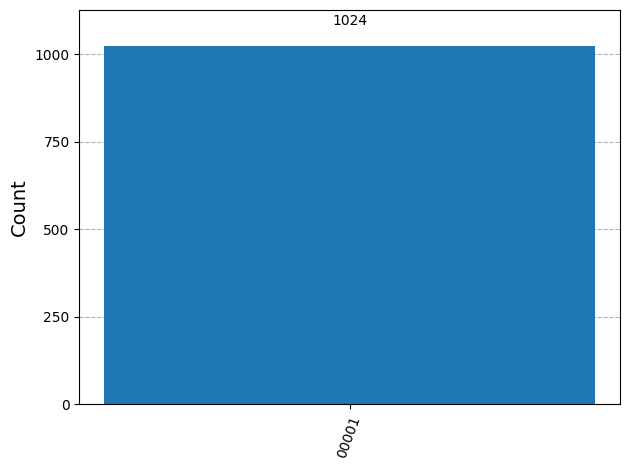

Histograma para fase: 0.125


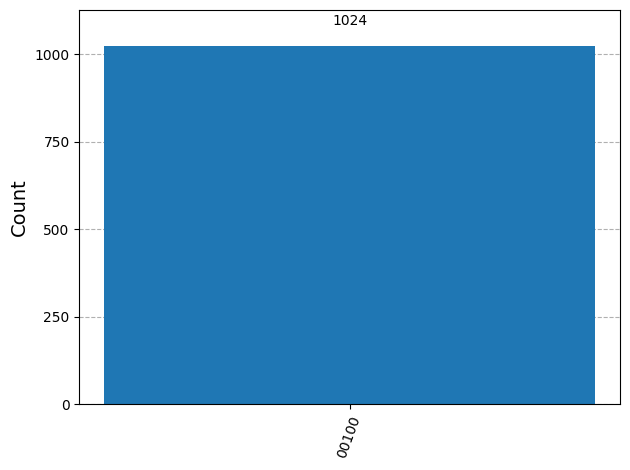

Histograma para fase: 1/e


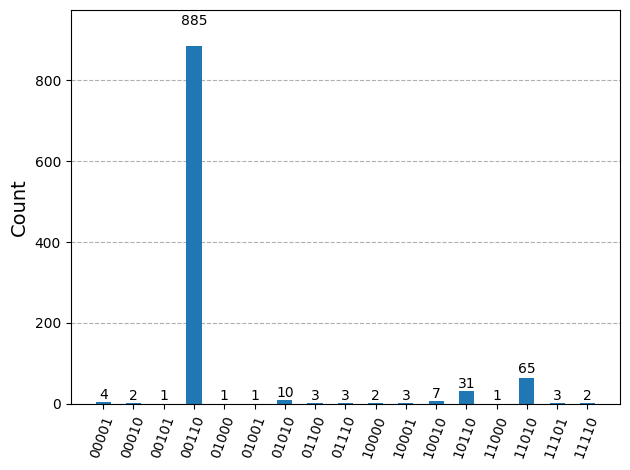

Histograma para fase: 1/pi


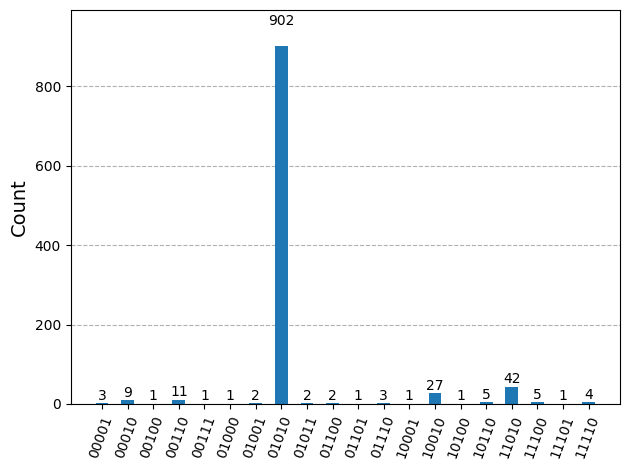

In [17]:
for nombre, counts in resultados.items():
    print("Histograma para fase:", nombre)
    display(plot_histogram(counts))

Comparación teórica (aprox)

In [18]:
for nombre, theta in fases.items():
    m = round(32 * theta)
    binario = format(m, "05b")
    fase_recuperada = m / 32

    print("Fase:", nombre)
    print("32θ =", 32 * theta)
    print("m aproximado =", m)
    print("Resultado binario esperado =", binario)
    print("Fase recuperada =", fase_recuperada)
    print()

Fase: 0.5
32θ = 16.0
m aproximado = 16
Resultado binario esperado = 10000
Fase recuperada = 0.5

Fase: 0.125
32θ = 4.0
m aproximado = 4
Resultado binario esperado = 00100
Fase recuperada = 0.125

Fase: 1/e
32θ = 11.772142117486155
m aproximado = 12
Resultado binario esperado = 01100
Fase recuperada = 0.375

Fase: 1/pi
32θ = 10.185916357881302
m aproximado = 10
Resultado binario esperado = 01010
Fase recuperada = 0.3125



Para $\theta = 0.5$, el algoritmo recuperó el estado $00001$, que al invertir el orden de bits corresponde a $10000$, exactamente el valor teórico esperado. Esto representa la fase $\frac{16}{32} = 0.5$, por lo que la estimación fue exacta y toda la probabilidad se concentró en un único estado.

---

Para $\theta = 0.125$, el algoritmo recuperó directamente el estado $00100$ (simetrico), coincidiendo completamente con la predicción teórica, ya que $32\theta = 4$. La fase recuperada fue $\frac{4}{32} = 0.125$, mostrando nuevamente una estimación exacta debido a que la fase puede representarse exactamente con 5 qubits.

---

Para $\theta = \frac{1}{e} \approx 0.367879$, el estado dominante obtenido fue $00110$, que al invertir el orden de bits corresponde a $01100$, el resultado esperado teóricamente. Esto aproxima la fase como $\frac{12}{32} = 0.375$. También aparecieron estados cercanos con menor probabilidad porque la fase no puede representarse exactamente usando únicamente 5 qubits.

---

Para $\theta = \frac{1}{\pi} \approx 0.31831$, el algoritmo recuperó principalmente el estado $01010$, coincidiendo con la aproximación teórica esperada. Esto corresponde a la fase $\frac{10}{32} = 0.3125$. Al igual que en el caso anterior, aparecieron otros estados cercanos debido a que la representación binaria de la fase no es exacta con 5 qubits.